# GNN

### Content   <a name="content"></a>

1. [Set a "seed" for all the libraries involved in the randomness](#1)
2. [Upload the datasets](#2)
3. [Create the GNN dataset ](#3)
4. [GNN](#4)
5. [Training loop](#5)
6. [Validation](#6)
7. [Evaluation](#7)

## Set a "seed" for all the libraries involved in the randomness <a name="1"></a>

In [1]:
import torch
import numpy as np
import random
import os

def set_seed(seed=42):
    # Set seed for Python's random module
    random.seed(seed)
    
    # Set seed for NumPy
    np.random.seed(seed)
    
    # Set seed for PyTorch
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # If using multi-GPU
    
    # Ensure deterministic operations in PyTorch
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# Run this once at the start of your notebook
set_seed(42)

## Upload the datasets <a name="2"></a>

In [2]:
# !pip install --upgrade numexpr

In [3]:
import pandas as pd

# 1. Load your master CSV dataset
df = pd.read_csv('AID499704_CIDs_SIDs_SMILESs_targets.csv') 

df['target'].value_counts()

target
1    1132
0     993
Name: count, dtype: int64

In [4]:
from sklearn.model_selection import train_test_split

train, temp = train_test_split(df, test_size=0.2, random_state=42)
val, test = train_test_split(temp, test_size=0.5, random_state=42)

print(f"Train size: {len(train)}")
print(f"Val size:   {len(val)}")
print(f"Test size:  {len(test)}")

Train size: 1700
Val size:   212
Test size:  213


In [5]:
print(train.shape)
train.head()

(1700, 4)


,CID,SID,SMILES,target
192,723526,103709905,C1=CC=C(C=C1)CCN2C(=NNC2=S)C3=CC=NC=C3,1
1232,12166995,103710665,CC[C@H]1CN2CC[C@@H]1C[C@@H]2[C@H](C3=C4C=C(C=C...,1
480,2951665,103713101,C1CC(CCC1CN2C(=O)C3=CC=CC=C3NC2=S)C(=O)NCCC4=C...,1
1110,826108,103709705,CCCC1=C(NC2=C(C1=O)C=C(C=C2)Br)C,1
1302,2835722,103713338,C1CCN(CC1)C2=C(C(=C(C=C2C(=O)N3CC(=O)NC4=CC=CC...,1


In [6]:
print(test.shape)
test.head()

(213, 4)


,CID,SID,SMILES,target
817,24052388,103711300,CCCCN(C)C(=O)C1=C(C2=C(S1)N=CN(C2=O)CC(=O)N(CC...,0
422,5334245,103710954,C1=CC=C2C(=C1)C(=CN2CC3=C(C=C(C=C3)Cl)Cl)/C=C(...,1
715,3132590,103713061,CCOC(=O)C1=C(NC2=C(C1C3=C(C=C(C=C3)Cl)Cl)C(=O)...,1
1469,135440409,103710901,CCN1C(=NN(C1=S)CN2CCN(CC2)CC3=CC4=C(C=C3)OCO4)...,0
1231,16237397,103709881,CCCCCCCCCCOC(=O)CN1C(=[N+](C2=CC=CC=C21)C)C.[Cl-],1


In [7]:
print(val.shape)
val.head()

(212, 4)


,CID,SID,SMILES,target
1680,6616740,103712208,COCCNC(=O)C1=CC(=C(C=C1)NCCC2=CC=C(C=C2)Cl)S(=...,1
964,45488650,103711690,CC(C)CNC(=O)C1=CN=C(N=C1NC2CCCC2)NCCCN,1
1823,45488866,103712640,CC1CCN(CC1)CC2=CC=C(C=C2)NC(=O)C3=CC4=C(S3)C5=...,1
270,45488399,103710451,CCCCCN(C(CC)C1=NC2=CC=CC=C2C(=O)N1C3=CC=CC=C3O...,0
2013,45489144,103713971,CC1=CC(=CC(=[N+]1OC(=O)N(C2=CC=CC=C2)C3=CC=CC=...,1


[<a href="#content">Back to top</a>]

## Create the dataset for GNN  <a name="3"></a>

In [8]:
from torch_geometric.data import Data
from rdkit import Chem

def df_to_graph(row):
    # 1. Convert SMILES to an RDKit molecule object
    mol = Chem.MolFromSmiles(row['SMILES'])
    
    # Optional: Handle cases where RDKit fails to parse the SMILES
    if mol is None:
        return None 
        
    node_features = []
    for atom in mol.GetAtoms():
        # A 6-dimensional feature vector for every single atom
        features = [
            atom.GetAtomicNum(),           # 1. Identity
            atom.GetDegree(),              # 2. Connectivity
            int(atom.GetIsAromatic()),     # 3. Heme-stacking ability
            atom.GetFormalCharge(),        # 4. Vacuole pH interaction
            atom.GetTotalNumHs(),          # 5. Saturation
            int(atom.GetProp('_BinaryHB')) if atom.HasProp('_BinaryHB') else 0 # 6. HB Logic
        ]
        node_features.append(features)
        
    x = torch.tensor(node_features, dtype=torch.float)
    
    edge_index = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edge_index.append([i, j])
        edge_index.append([j, i])
        
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    
    return Data(x=x, edge_index=edge_index, y=torch.tensor([row['target']], dtype=torch.float))

# Update the graph creation step to filter out any None results
train_graphs = [g for g in [df_to_graph(row) for _, row in train.iterrows()] if g is not None]
val_graphs = [g for g in [df_to_graph(row) for _, row in val.iterrows()] if g is not None]
test_graphs = [g for g in [df_to_graph(row) for _, row in test.iterrows()] if g is not None]

In [9]:
from torch_geometric.loader import DataLoader

# Create batches (e.g., batch size 32)
train_loader = DataLoader(train_graphs, batch_size=32, shuffle=True)
val_loader = DataLoader(val_graphs, batch_size=32)
test_loader = DataLoader(test_graphs, batch_size=32)

[<a href="#content">Back to top</a>]

## GNN  <a name="4"></a>

In [10]:
from torch_geometric.nn import GCNConv, global_mean_pool
import torch.nn.functional as F

class GNNEncoder(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.conv1 = GCNConv(input_dim, hidden_dim)
        self.bn1 = torch.nn.BatchNorm1d(hidden_dim)
        
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.bn2 = torch.nn.BatchNorm1d(hidden_dim)
        
        self.conv3 = GCNConv(hidden_dim, latent_dim)
        self.bn3 = torch.nn.BatchNorm1d(latent_dim) # Added consistency
        
        self.classifier = torch.nn.Linear(latent_dim, 1)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
    
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.relu(self.bn3(self.conv3(x, edge_index))) # Hierarchical understanding
    
        # Aggregate node features to graph level
        x = global_mean_pool(x, batch)
    
        return self.classifier(x)

[<a href="#content">Back to top</a>]

## Trainign loop <a name="5"></a>

In [11]:
import torch.optim as optim
from torch_geometric.nn import GCNConv, global_mean_pool

# 1. Initialize the Hybrid Model (from previous steps)
input_dim = 6      # Number of features per node
hidden_dim = 64    # Size of hidden layers
latent_dim = 32    # Size of the output embedding

# Initialize with the required arguments
model = GNNEncoder(input_dim, hidden_dim, latent_dim)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
criterion = torch.nn.BCEWithLogitsLoss()

# 2. Training Function
def train_one_epoch(loader):
    model.train()
    total_loss = 0
    for batch in loader:
        optimizer.zero_grad()
        
        # Now 'batch' is passed as the single 'data' argument
        output = model(batch) 
        
        # Ensure dimensions match: flatten both to [batch_size]
        loss = criterion(output.view(-1), batch.y.view(-1))
        
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    return total_loss / len(loader)

# 3. Execution
for epoch in range(50):
    loss = train_one_epoch(train_loader)
    print(f"Epoch {epoch+1}, Loss: {loss:.4f}")

Epoch 1, Loss: 0.6678
Epoch 2, Loss: 0.6529
Epoch 3, Loss: 0.6483
Epoch 4, Loss: 0.6499
Epoch 5, Loss: 0.6396
Epoch 6, Loss: 0.6395
Epoch 7, Loss: 0.6334
Epoch 8, Loss: 0.6368
Epoch 9, Loss: 0.6357
Epoch 10, Loss: 0.6328
Epoch 11, Loss: 0.6272
Epoch 12, Loss: 0.6346
Epoch 13, Loss: 0.6281
Epoch 14, Loss: 0.6285
Epoch 15, Loss: 0.6254
Epoch 16, Loss: 0.6198
Epoch 17, Loss: 0.6246
Epoch 18, Loss: 0.6234
Epoch 19, Loss: 0.6256
Epoch 20, Loss: 0.6188
Epoch 21, Loss: 0.6189
Epoch 22, Loss: 0.6267
Epoch 23, Loss: 0.6216
Epoch 24, Loss: 0.6107
Epoch 25, Loss: 0.6171
Epoch 26, Loss: 0.6082
Epoch 27, Loss: 0.6141
Epoch 28, Loss: 0.6113
Epoch 29, Loss: 0.6061
Epoch 30, Loss: 0.6064
Epoch 31, Loss: 0.6061
Epoch 32, Loss: 0.6080
Epoch 33, Loss: 0.6074
Epoch 34, Loss: 0.6114
Epoch 35, Loss: 0.6071
Epoch 36, Loss: 0.6087
Epoch 37, Loss: 0.6114
Epoch 38, Loss: 0.6062
Epoch 39, Loss: 0.6182
Epoch 40, Loss: 0.5965
Epoch 41, Loss: 0.6000
Epoch 42, Loss: 0.5960
Epoch 43, Loss: 0.6031
Epoch 44, Loss: 0.59

[<a href="#content">Back to top</a>]

## Validation <a name="6"></a>

In [12]:
best_val_loss = float('inf')

def validate(loader):
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for batch in loader:
            output = model(batch)
            # Use .view(-1) to ensure both are 1D tensors of the same length
            loss = criterion(output.view(-1), batch.y.view(-1).float())
            val_loss += loss.item()
    return val_loss / len(loader)

# --- Combined Training and Validation ---
for epoch in range(50):
    train_loss = train_one_epoch(train_loader)
    val_loss = validate(val_loader)
    
    print(f"Epoch {epoch+1:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    
    # Save the model if it's the best one so far
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'best_hybrid_model.pth')

Epoch 001 | Train Loss: 0.5939 | Val Loss: 0.6672
Epoch 002 | Train Loss: 0.5888 | Val Loss: 0.5950
Epoch 003 | Train Loss: 0.5902 | Val Loss: 0.6164
Epoch 004 | Train Loss: 0.5886 | Val Loss: 0.5905
Epoch 005 | Train Loss: 0.5791 | Val Loss: 0.6068
Epoch 006 | Train Loss: 0.5880 | Val Loss: 0.5923
Epoch 007 | Train Loss: 0.5905 | Val Loss: 0.6017
Epoch 008 | Train Loss: 0.5866 | Val Loss: 0.5944
Epoch 009 | Train Loss: 0.5911 | Val Loss: 0.5938
Epoch 010 | Train Loss: 0.5874 | Val Loss: 0.6381
Epoch 011 | Train Loss: 0.5873 | Val Loss: 0.5981
Epoch 012 | Train Loss: 0.5789 | Val Loss: 0.5834
Epoch 013 | Train Loss: 0.5862 | Val Loss: 0.5924
Epoch 014 | Train Loss: 0.5822 | Val Loss: 0.6558
Epoch 015 | Train Loss: 0.5800 | Val Loss: 0.5938
Epoch 016 | Train Loss: 0.5772 | Val Loss: 0.6281
Epoch 017 | Train Loss: 0.5822 | Val Loss: 0.5915
Epoch 018 | Train Loss: 0.5780 | Val Loss: 0.6992
Epoch 019 | Train Loss: 0.5776 | Val Loss: 0.6032
Epoch 020 | Train Loss: 0.5726 | Val Loss: 0.6001


[<a href="#content">Back to top</a>]

## Evaluation  <a name="7"></a>

In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Update the signature to accept 'model'
def evaluate_model(loader, model): 
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for batch in loader:
            # 1. Get raw output (logits)
            logits = model(batch).view(-1)
            
            # 2. Convert to probabilities (Sigmoid) then to 0 or 1
            # This is critical because BCEWithLogitsLoss outputs raw numbers
            probs = torch.sigmoid(logits)
            preds = (probs > 0.5).float()
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch.y.cpu().numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    rec = recall_score(all_labels, all_preds, zero_division=0)
    f1 = f1_score(all_labels, all_preds, zero_division=0)
    
    return acc, prec, rec, f1

# Now the call matches the definition
acc, prec, rec, f1 = evaluate_model(test_loader, model)
print(f"Test Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1-Score: {f1:.4f}")

Test Accuracy: 0.7042 | Precision: 0.7356 | Recall: 0.6154 | F1-Score: 0.6702


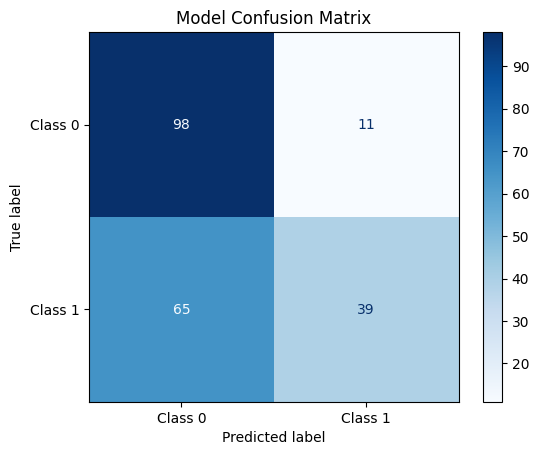

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def plot_confusion_matrix(loader, model):
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for batch in loader:
            output = model(batch)
            preds = (output > 0.5).float()
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(batch.y.cpu().numpy())
            
    cm = confusion_matrix(all_targets, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Class 0', 'Class 1'])
    disp.plot(cmap='Blues')
    plt.title("Model Confusion Matrix")
    plt.show()

# Usage:
plot_confusion_matrix(test_loader, model)

[<a href="#content">Back to top</a>]